<a href="https://colab.research.google.com/github/ottrindade1963/Analise-industrial-emergentes-Orfeu/blob/main/Treino_Avaliacao_Modelos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ottrindade1963/EXTRA-O-DE-DADOS-QUALITATIVOS-DE-PA-SES-EM-DESENVOLVIMENTO/blob/main/Treino_Avaliacao_Modelos.ipynb)

# Treino e Avaliação de Modelos

Treina e avalia 5 modelos nos 3 datasets agregados:
- **LSTM** — Rede neural recorrente com memória de longo prazo
- **Random Forest** — Ensemble de árvores de decisão
- **XGBoost** — Gradient boosting otimizado
- **SARIMAX** — Modelo sazonal autorregressivo com exógenas
- **TFT** — Transformer temporal (GRU + Attention)

In [1]:
# 1. Setup — Instalar dependências e clonar repositório
!pip install -q pandas numpy scikit-learn scipy statsmodels xgboost tensorflow openpyxl

import os, sys
REPO = "EXTRA-O-DE-DADOS-QUALITATIVOS-DE-PA-SES-EM-DESENVOLVIMENTO"
if os.path.exists(REPO):
    !rm -rf {REPO}
!git clone https://github.com/ottrindade1963/{REPO}.git
%cd {REPO}
sys.path.insert(0, ".")

# Verificar dados preparados na raiz
print("\n✓ Verificando dados preparados na raiz...\n")
datasets = ['inner', 'left', 'outer']
for ds in datasets:
    # Verificar ficheiro base de cada dataset
    f_teste = f"{ds}_trees_treino.csv"
    if os.path.exists(f_teste):
        print(f"✅ Dataset {ds.upper()}: Ficheiros encontrados na raiz")
    else:
        print(f"❌ Dataset {ds.upper()}: Ficheiro {f_teste} NÃO encontrado na raiz")
        print(f"   → Verifique se os ficheiros foram carregados para a raiz do repositório.")

Cloning into 'EXTRA-O-DE-DADOS-QUALITATIVOS-DE-PA-SES-EM-DESENVOLVIMENTO'...
remote: Enumerating objects: 353, done.
remote: Counting objects: 100% (75/75), done.
remote: Compressing objects: 100% (51/51), done.
remote: Total 353 (delta 63), reused 24 (delta 24), pack-reused 278 (from 2)
Receiving objects: 100% (353/353), 12.26 MiB | 19.46 MiB/s, done.
Resolving deltas: 100% (136/136), done.
/content/EXTRA-O-DE-DADOS-QUALITATIVOS-DE-PA-SES-EM-DESENVOLVIMENTO

✓ Verificando dados preparados na raiz...

✅ Dataset INNER: Ficheiros encontrados na raiz
✅ Dataset LEFT: Ficheiros encontrados na raiz
✅ Dataset OUTER: Ficheiros encontrados na raiz


In [2]:
# 2. Treinar e avaliar todos os modelos
from model_pipeline import executar_treino_avaliacao
resultados, tabelas = executar_treino_avaliacao()

╔════════════════════════════════════════════════════════════════════╗
║  TREINO E AVALIAÇÃO — 5 MODELOS × 3 DATASETS                     ║
╚════════════════════════════════════════════════════════════════════╝

╔════════════════════════════════════════════════════════════════════╗
║  TREINO E AVALIAÇÃO:                     INNER                      ║
╚════════════════════════════════════════════════════════════════════╝

  ── Random Forest ──
    Treino: (2475, 107) | Teste: (706, 107)
    ✅ Modelo treinado (200 árvores)
    ─────────────────────────────────────────────
    │ Métrica      │        Valor │
    ─────────────────────────────────────────────
    │ MAE          │     263.2445 │
    │ RMSE         │     593.9615 │
    │ R2           │       0.9938 │
    │ MAPE (%)     │         2.23 │
    │ SMAPE (%)    │         2.18 │
    ─────────────────────────────────────────────

    Top 10 Features:
      pib_per_capita_ppc_ma3                   0.9705
      pib_per_capita_ppc_lag1

    ─────────────────────────────────────────────
    │ Métrica      │        Valor │
    ─────────────────────────────────────────────
    │ MAE          │       0.0129 │
    │ RMSE         │       0.0197 │
    │ R2           │       0.9844 │
    │ MAPE (%)     │         8.43 │
    │ SMAPE (%)    │         7.96 │
    ─────────────────────────────────────────────

  ── SARIMAX ──
    Treino: (2705, 21) | Teste: (739, 21)
    Exógenas: 14 variáveis
    Treinando para 10 países (de 127 total)...
    ✅ Concluído: 10 países OK, 0 falhas
    ─────────────────────────────────────────────
    │ Métrica      │        Valor │
    ─────────────────────────────────────────────
    │ MAE          │     952.0971 │
    │ RMSE         │    1726.6273 │
    │ R2           │       0.9592 │
    │ MAPE (%)     │         9.21 │
    │ SMAPE (%)    │         8.57 │
    ─────────────────────────────────────────────

  ── Temporal Fusion Transformer ──
    ⚠️ pytorch-forecasting não disponível
    → Usando GRU

    ─────────────────────────────────────────────
    │ Métrica      │        Valor │
    ─────────────────────────────────────────────
    │ MAE          │        0.014 │
    │ RMSE         │       0.0208 │
    │ R2           │       0.9825 │
    │ MAPE (%)     │        10.03 │
    │ SMAPE (%)    │        10.19 │
    ─────────────────────────────────────────────

  ── SARIMAX ──
    Treino: (2659, 22) | Teste: (728, 22)
    Exógenas: 14 variáveis
    Treinando para 10 países (de 127 total)...
    ✅ Concluído: 10 países OK, 0 falhas
    ─────────────────────────────────────────────
    │ Métrica      │        Valor │
    ─────────────────────────────────────────────
    │ MAE          │     949.5309 │
    │ RMSE         │     1726.142 │
    │ R2           │       0.9592 │
    │ MAPE (%)     │         9.18 │
    │ SMAPE (%)    │         8.54 │
    ─────────────────────────────────────────────

  ── Temporal Fusion Transformer ──
    ⚠️ pytorch-forecasting não disponível
    → Usando GRU


════════════════════════════════════════════════════════════
  RESULTADOS: INNER
════════════════════════════════════════════════════════════

  01_real_vs_previsto.png


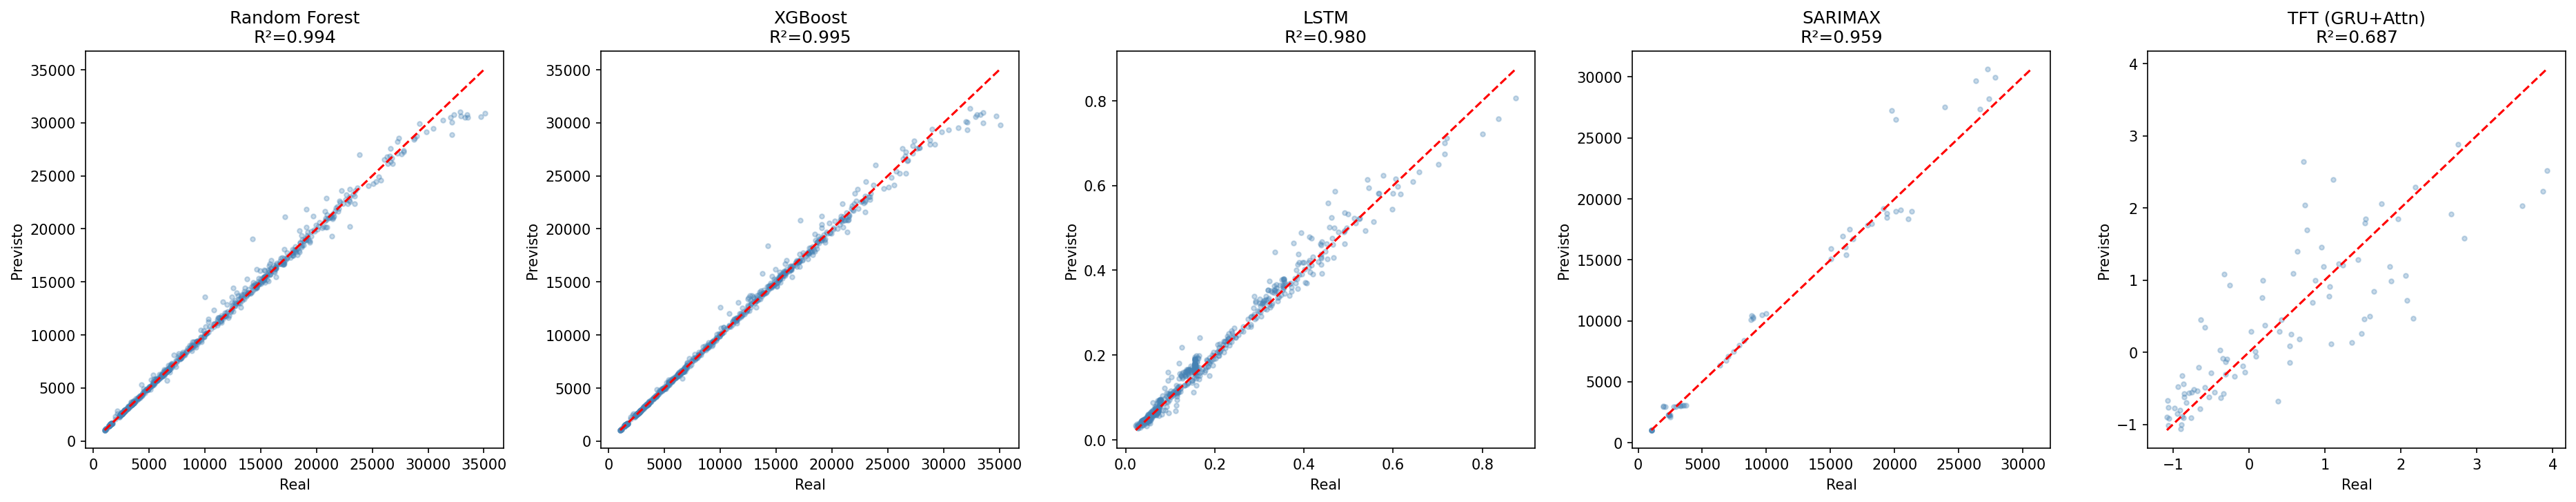


  02_comparacao_metricas.png


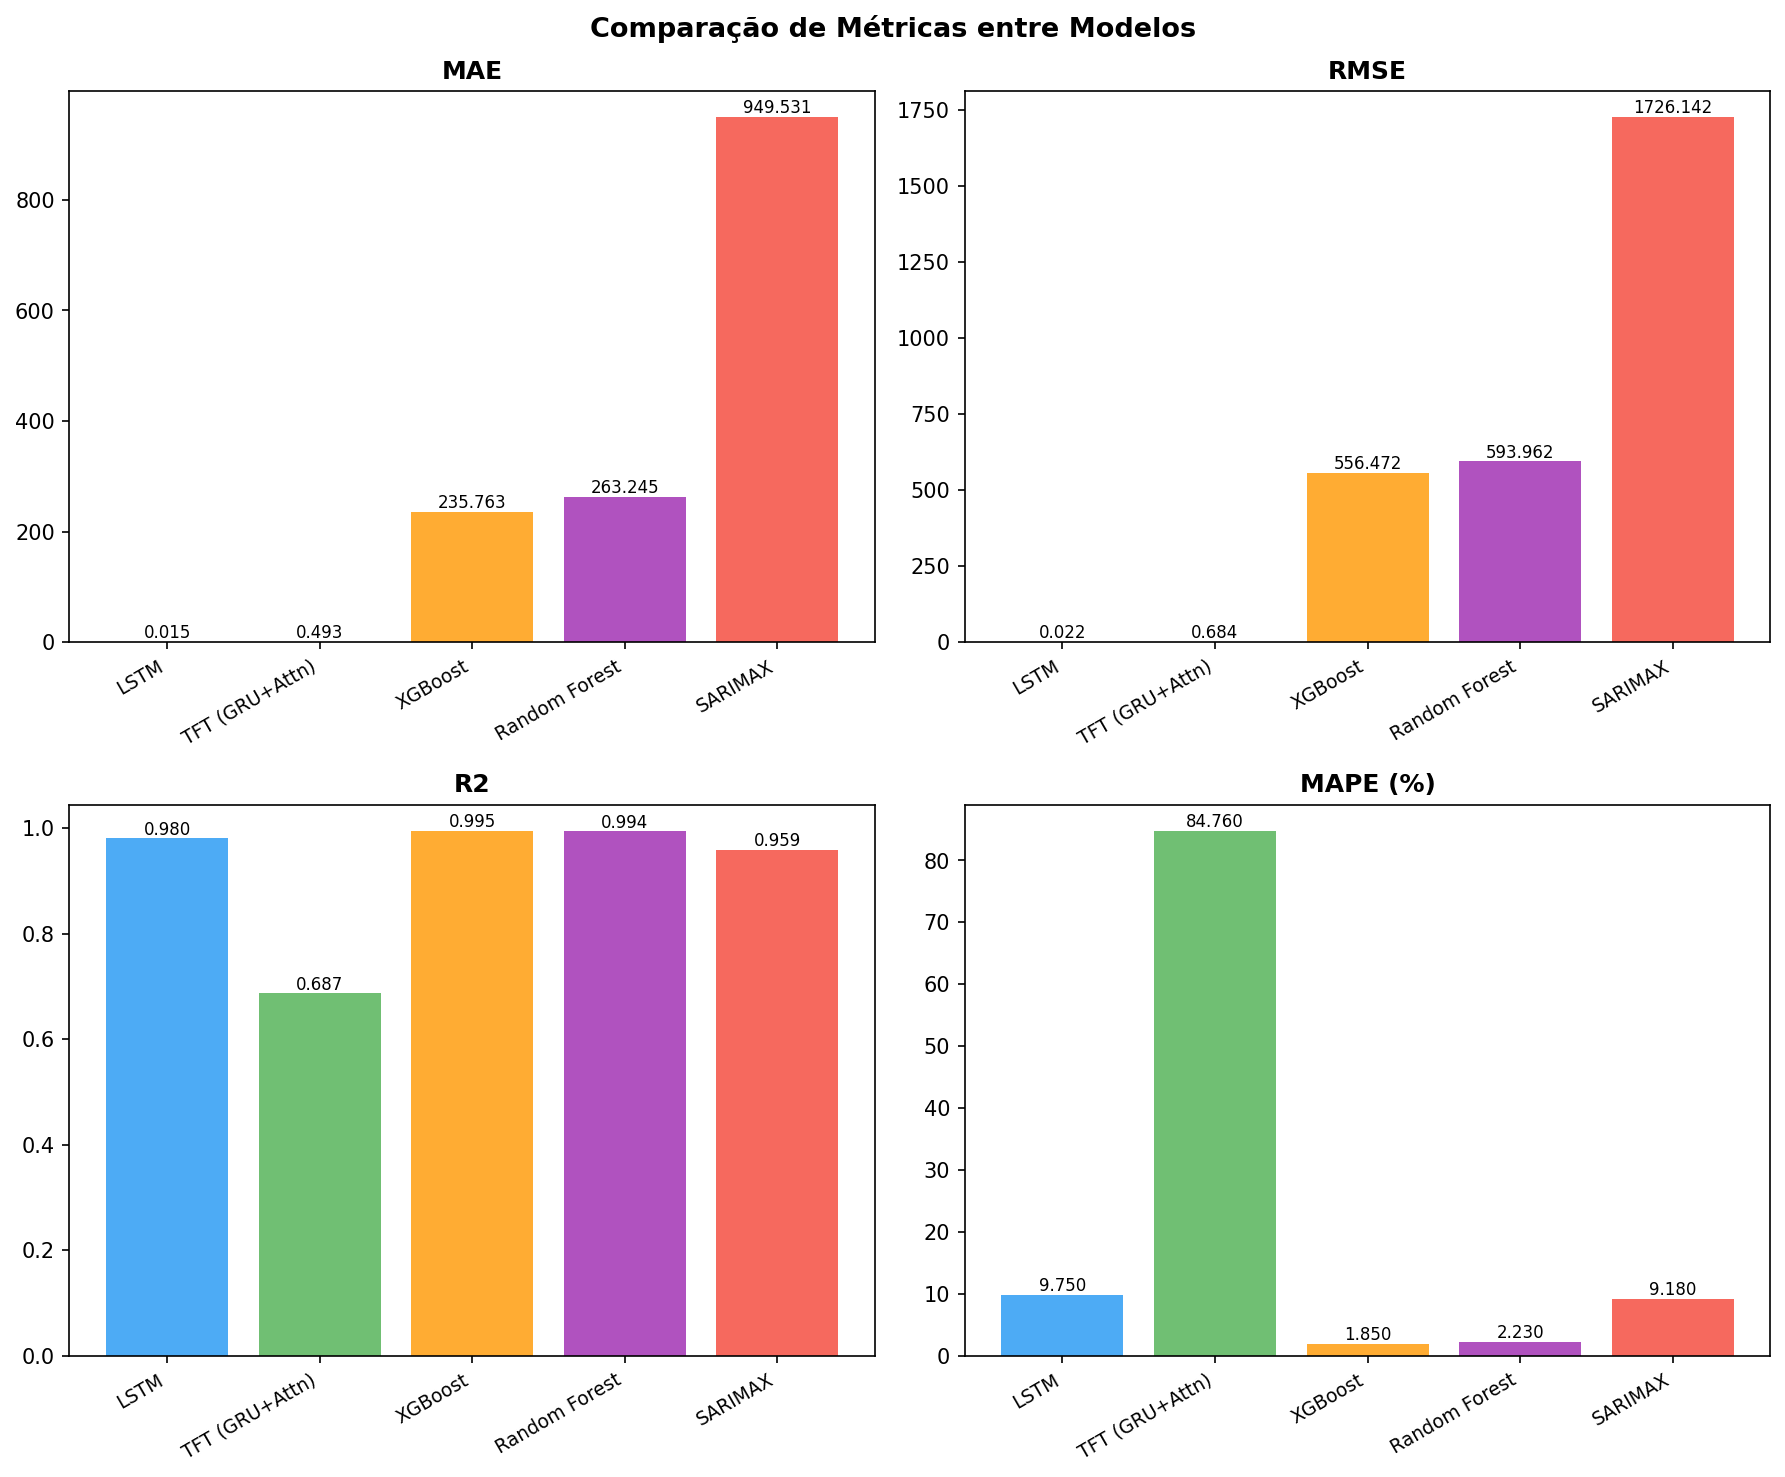


  03_distribuicao_residuos.png


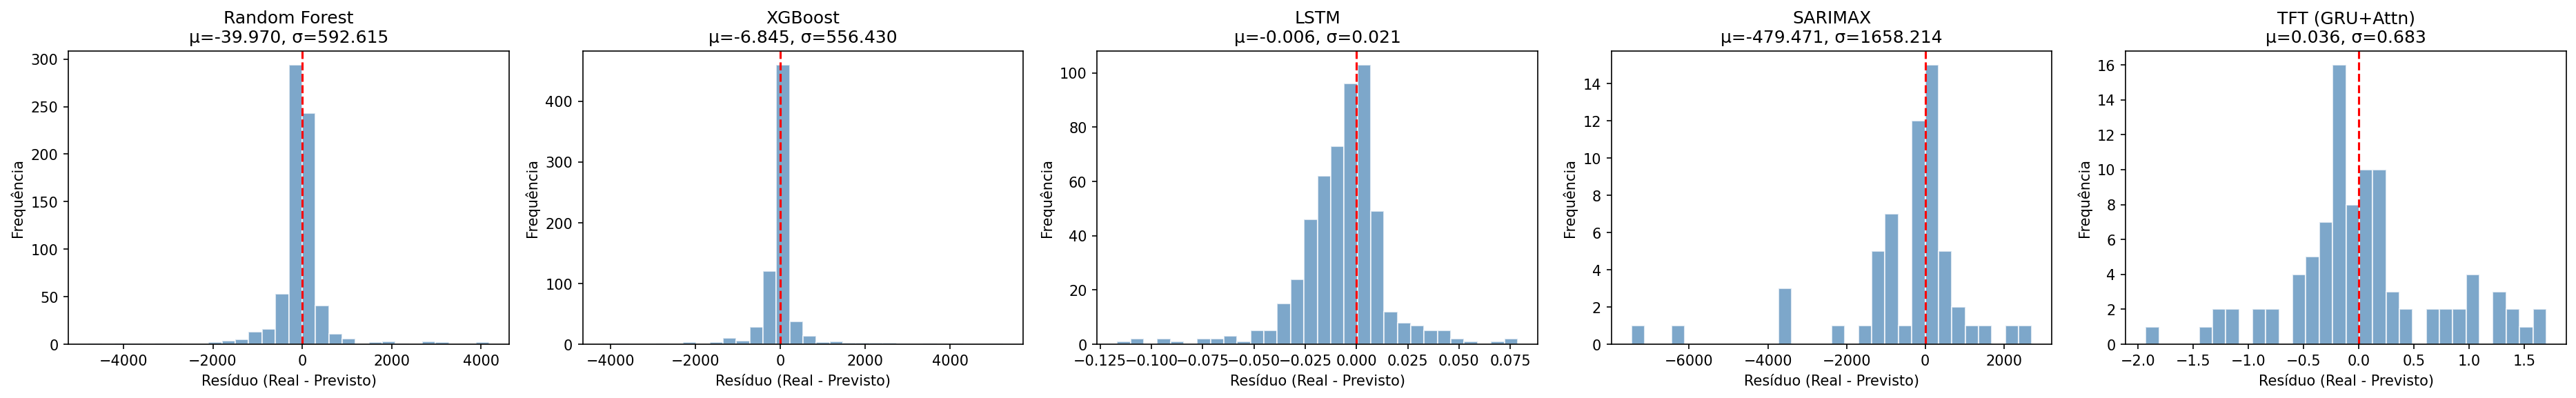


  04_ranking_modelos.png


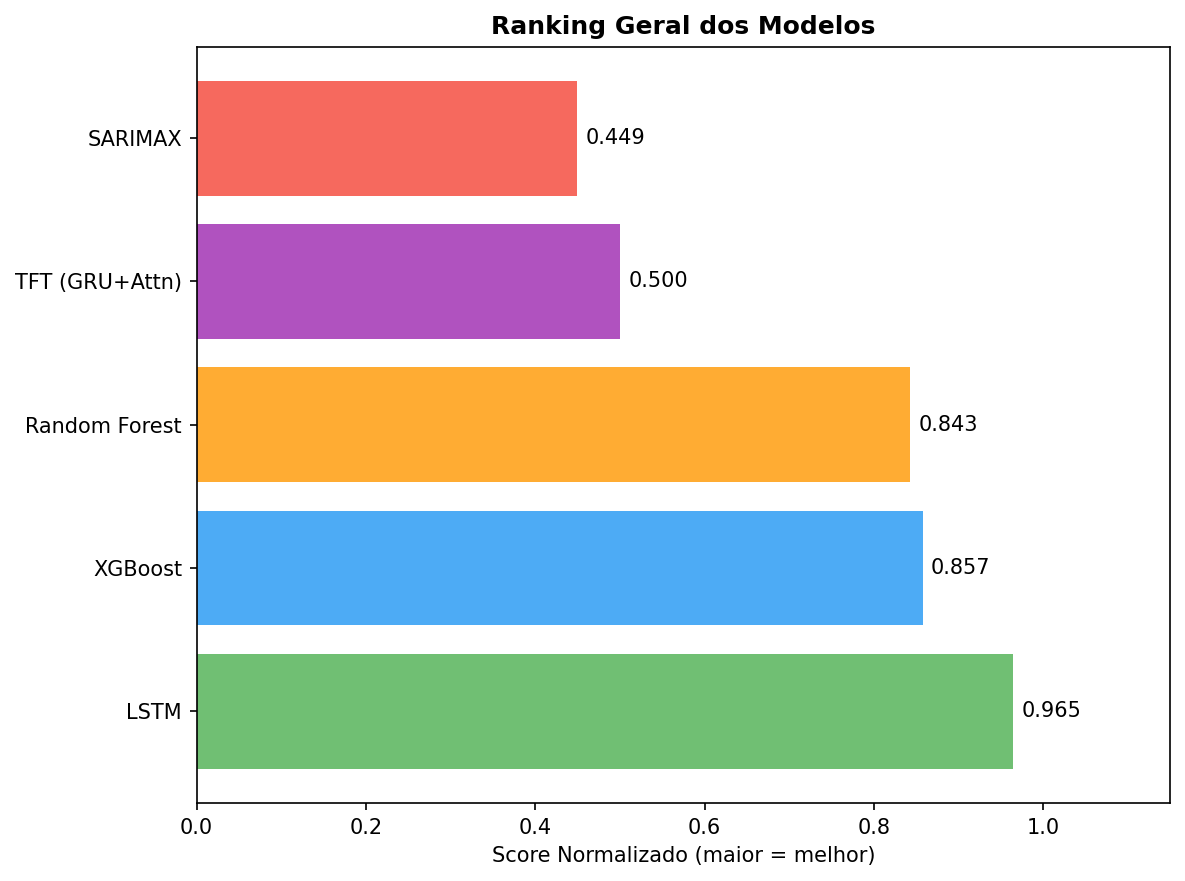


════════════════════════════════════════════════════════════
  RESULTADOS: LEFT
════════════════════════════════════════════════════════════

  01_real_vs_previsto.png


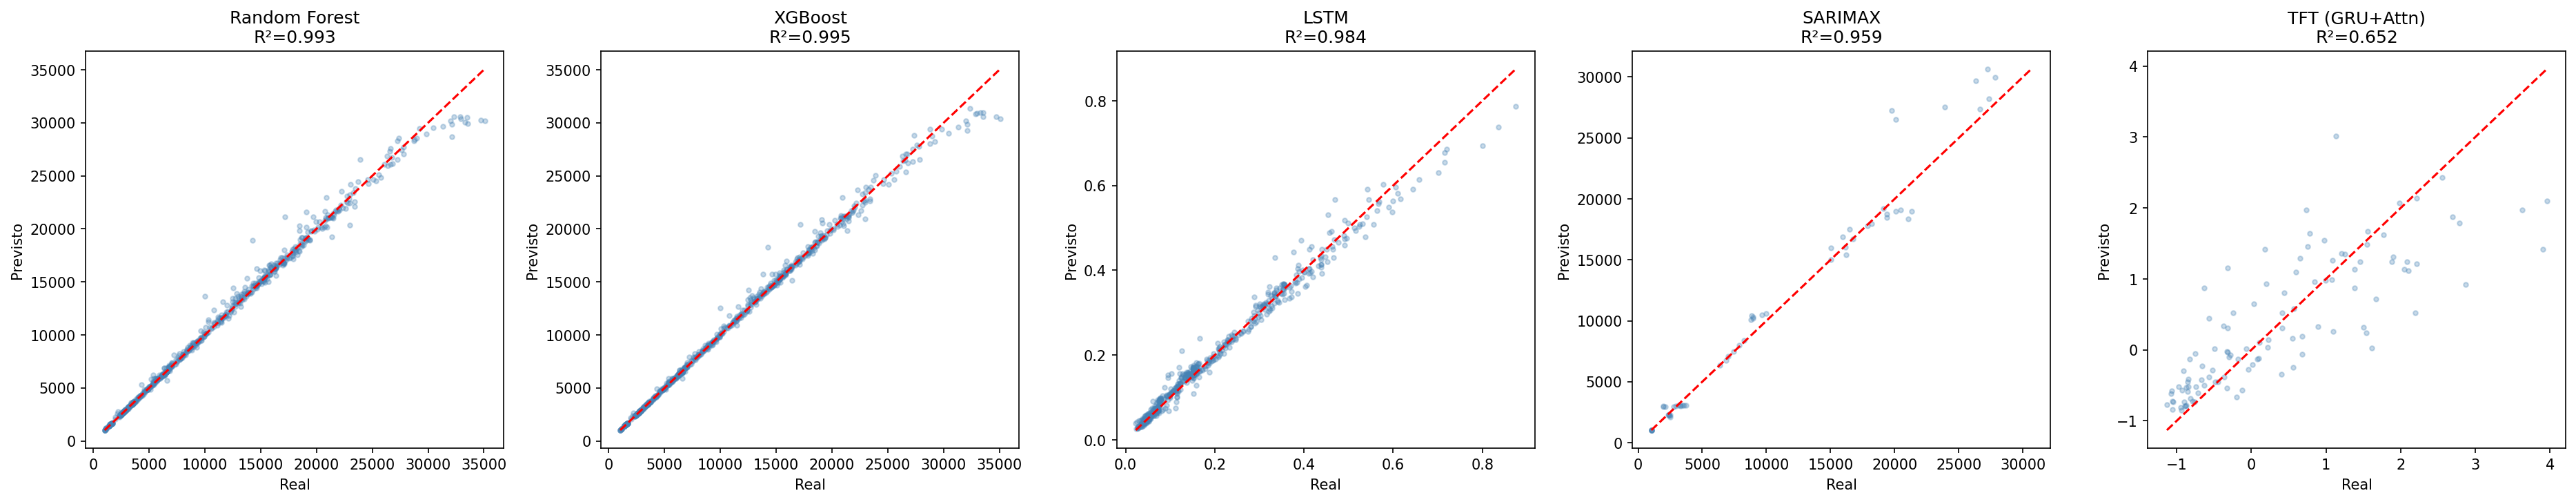


  02_comparacao_metricas.png


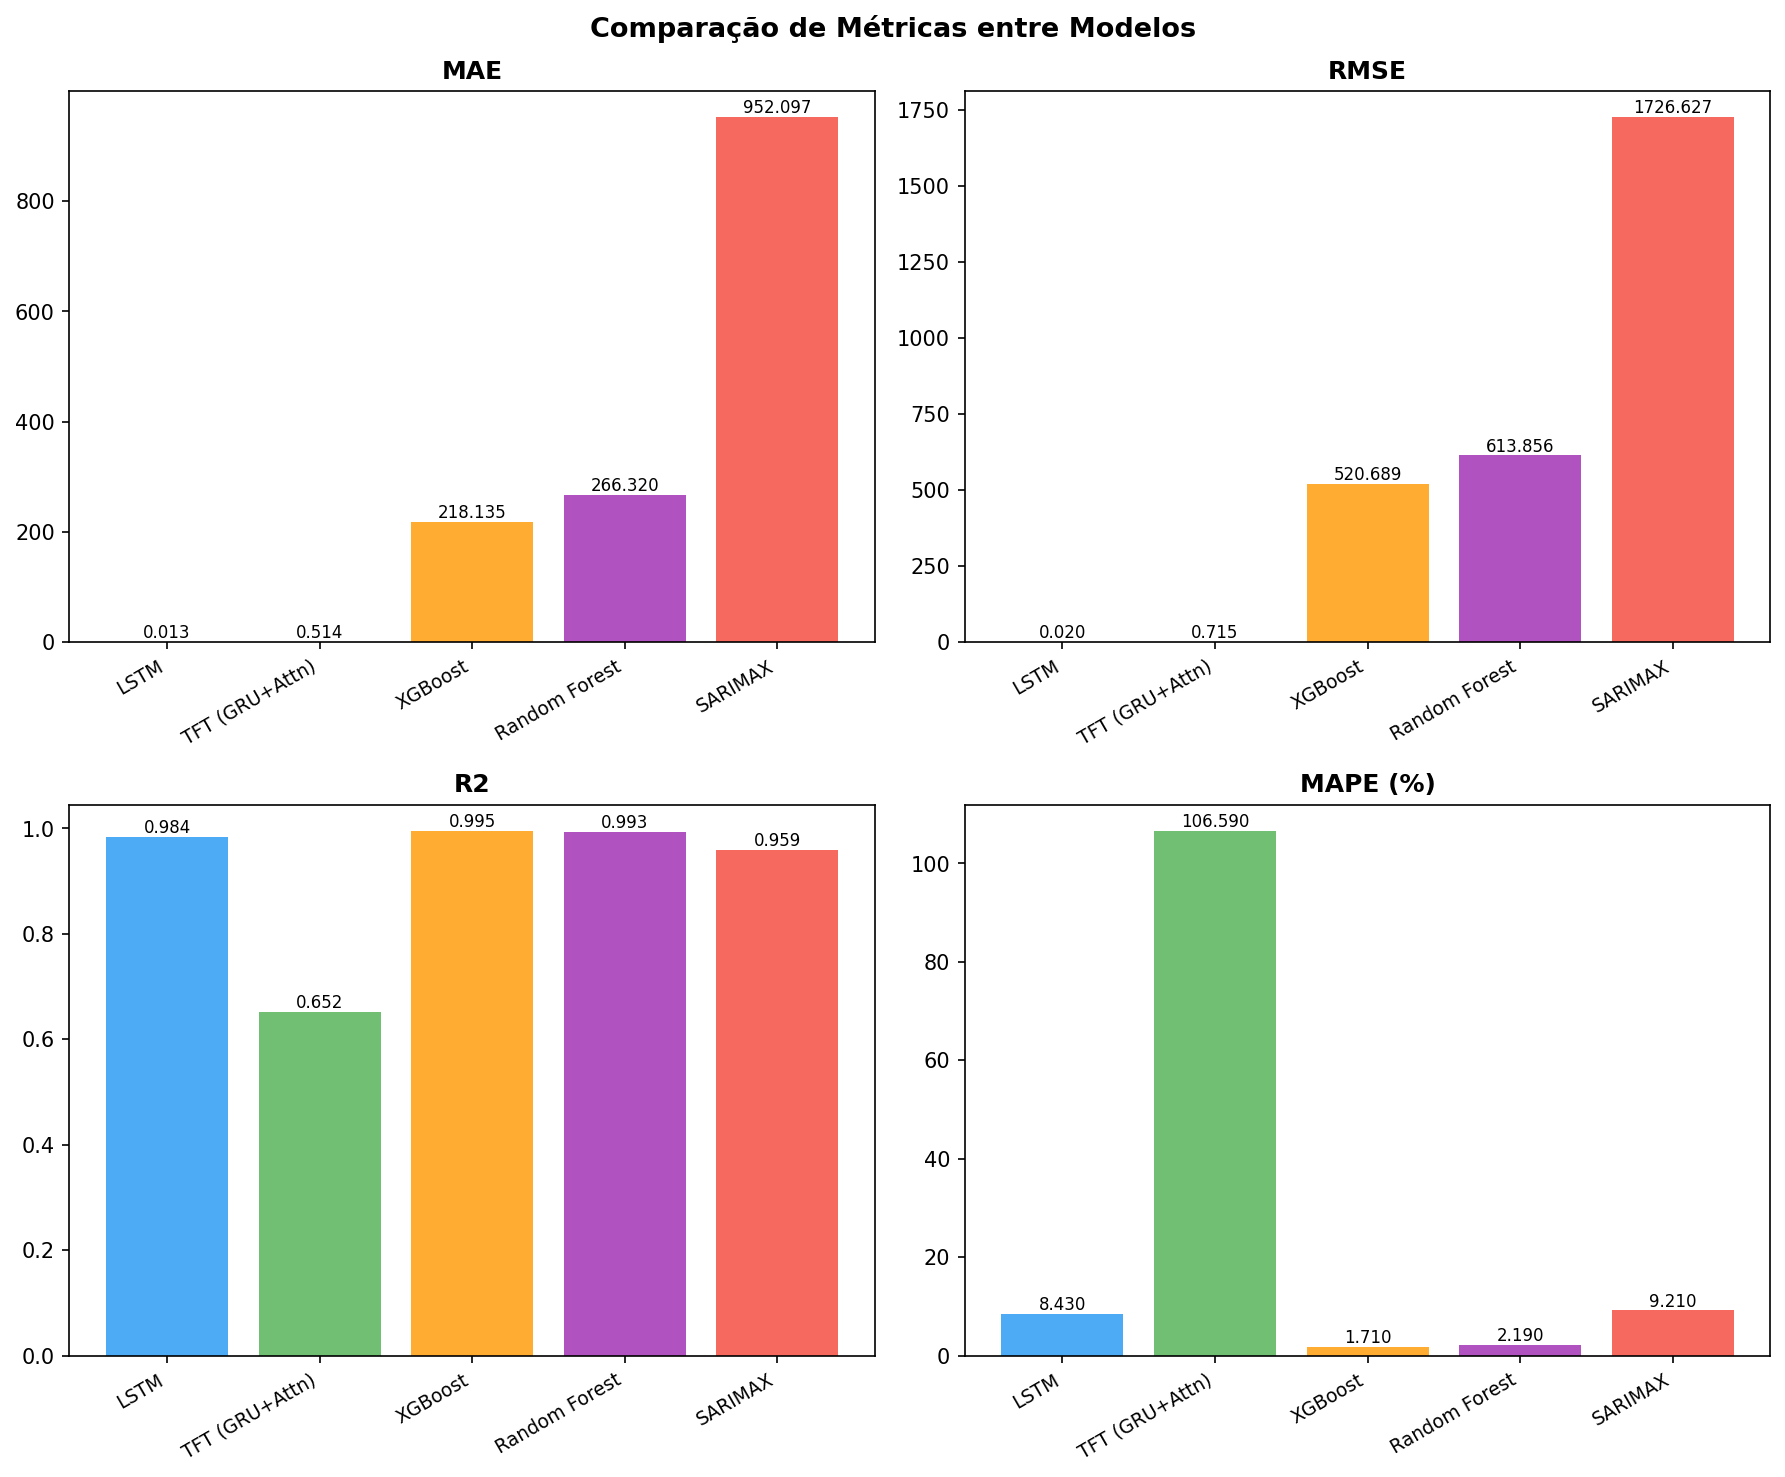


  03_distribuicao_residuos.png


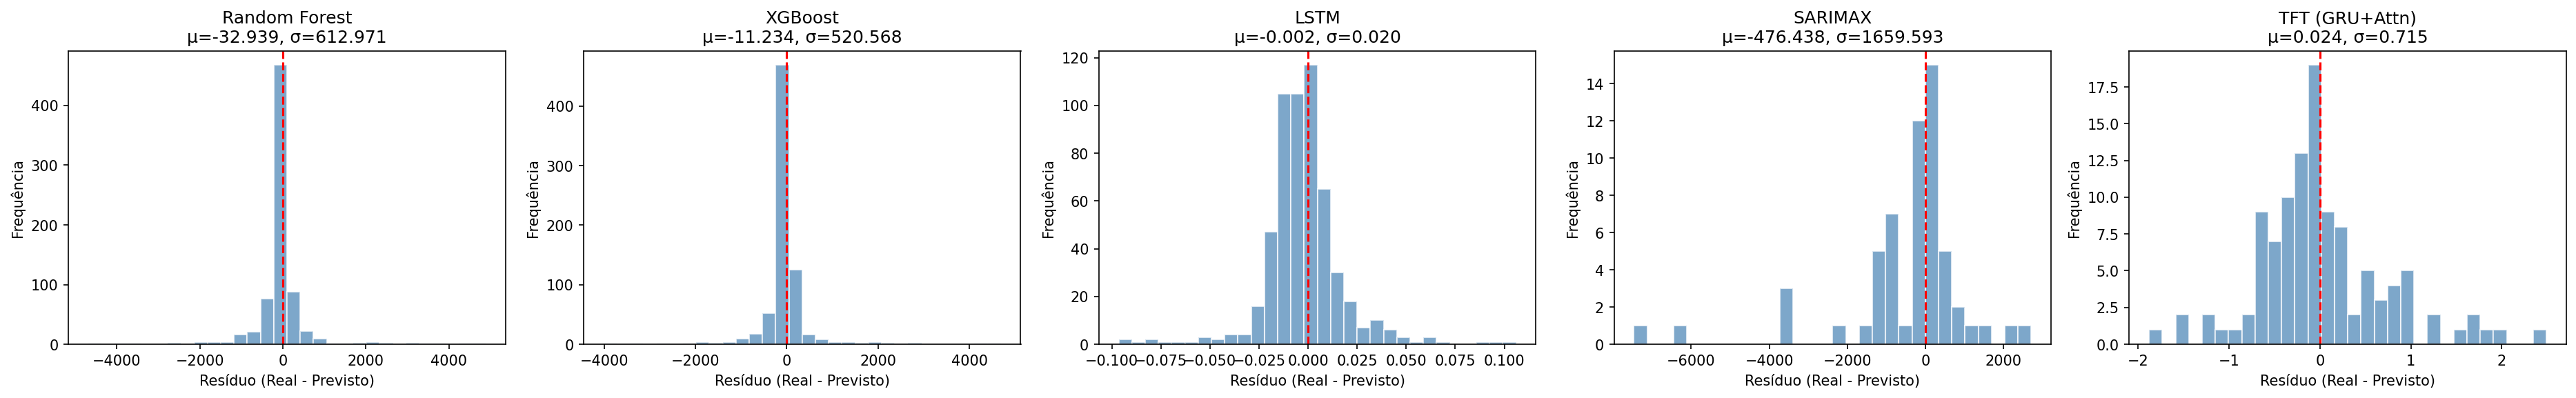


  04_ranking_modelos.png


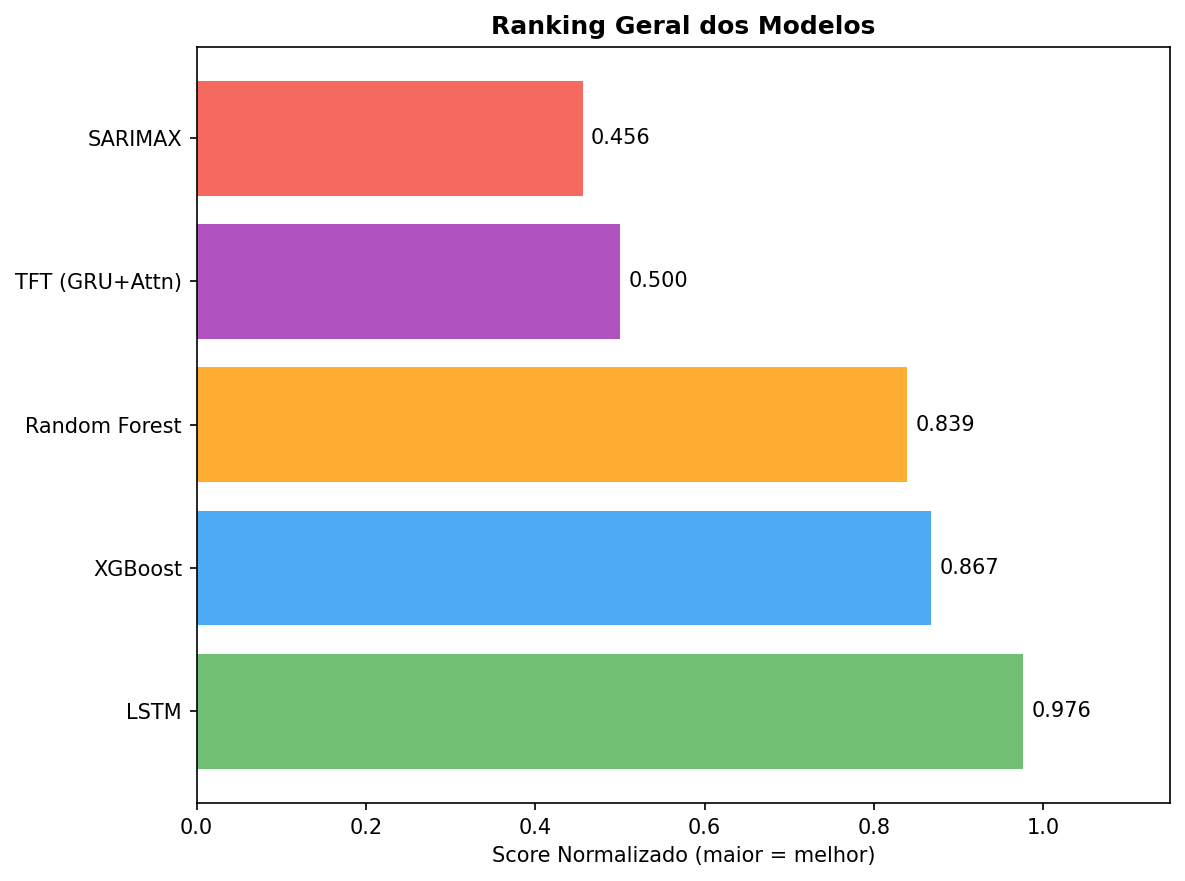


════════════════════════════════════════════════════════════
  RESULTADOS: OUTER
════════════════════════════════════════════════════════════

  01_real_vs_previsto.png


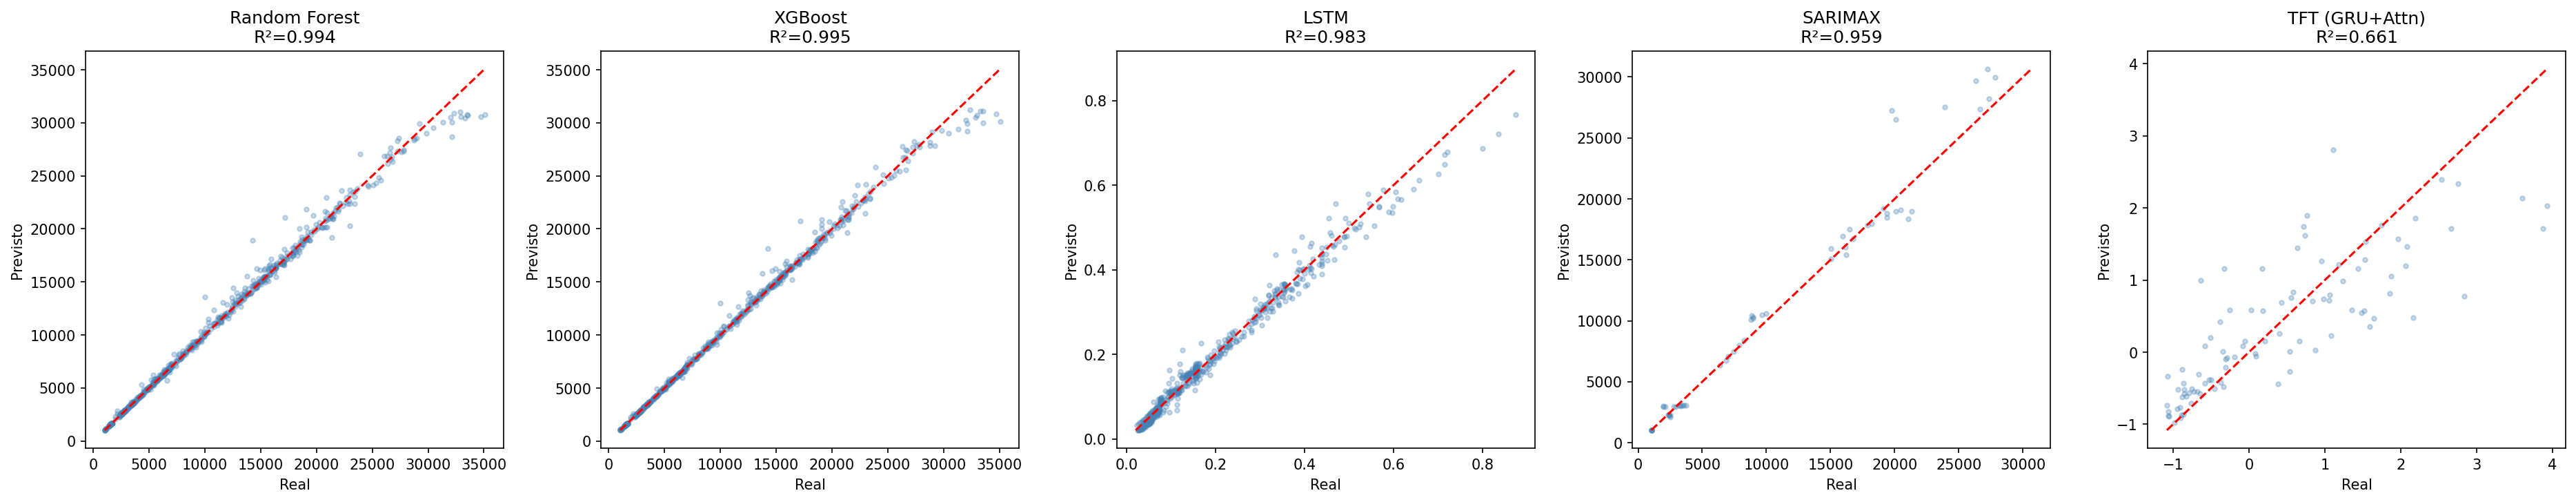


  02_comparacao_metricas.png


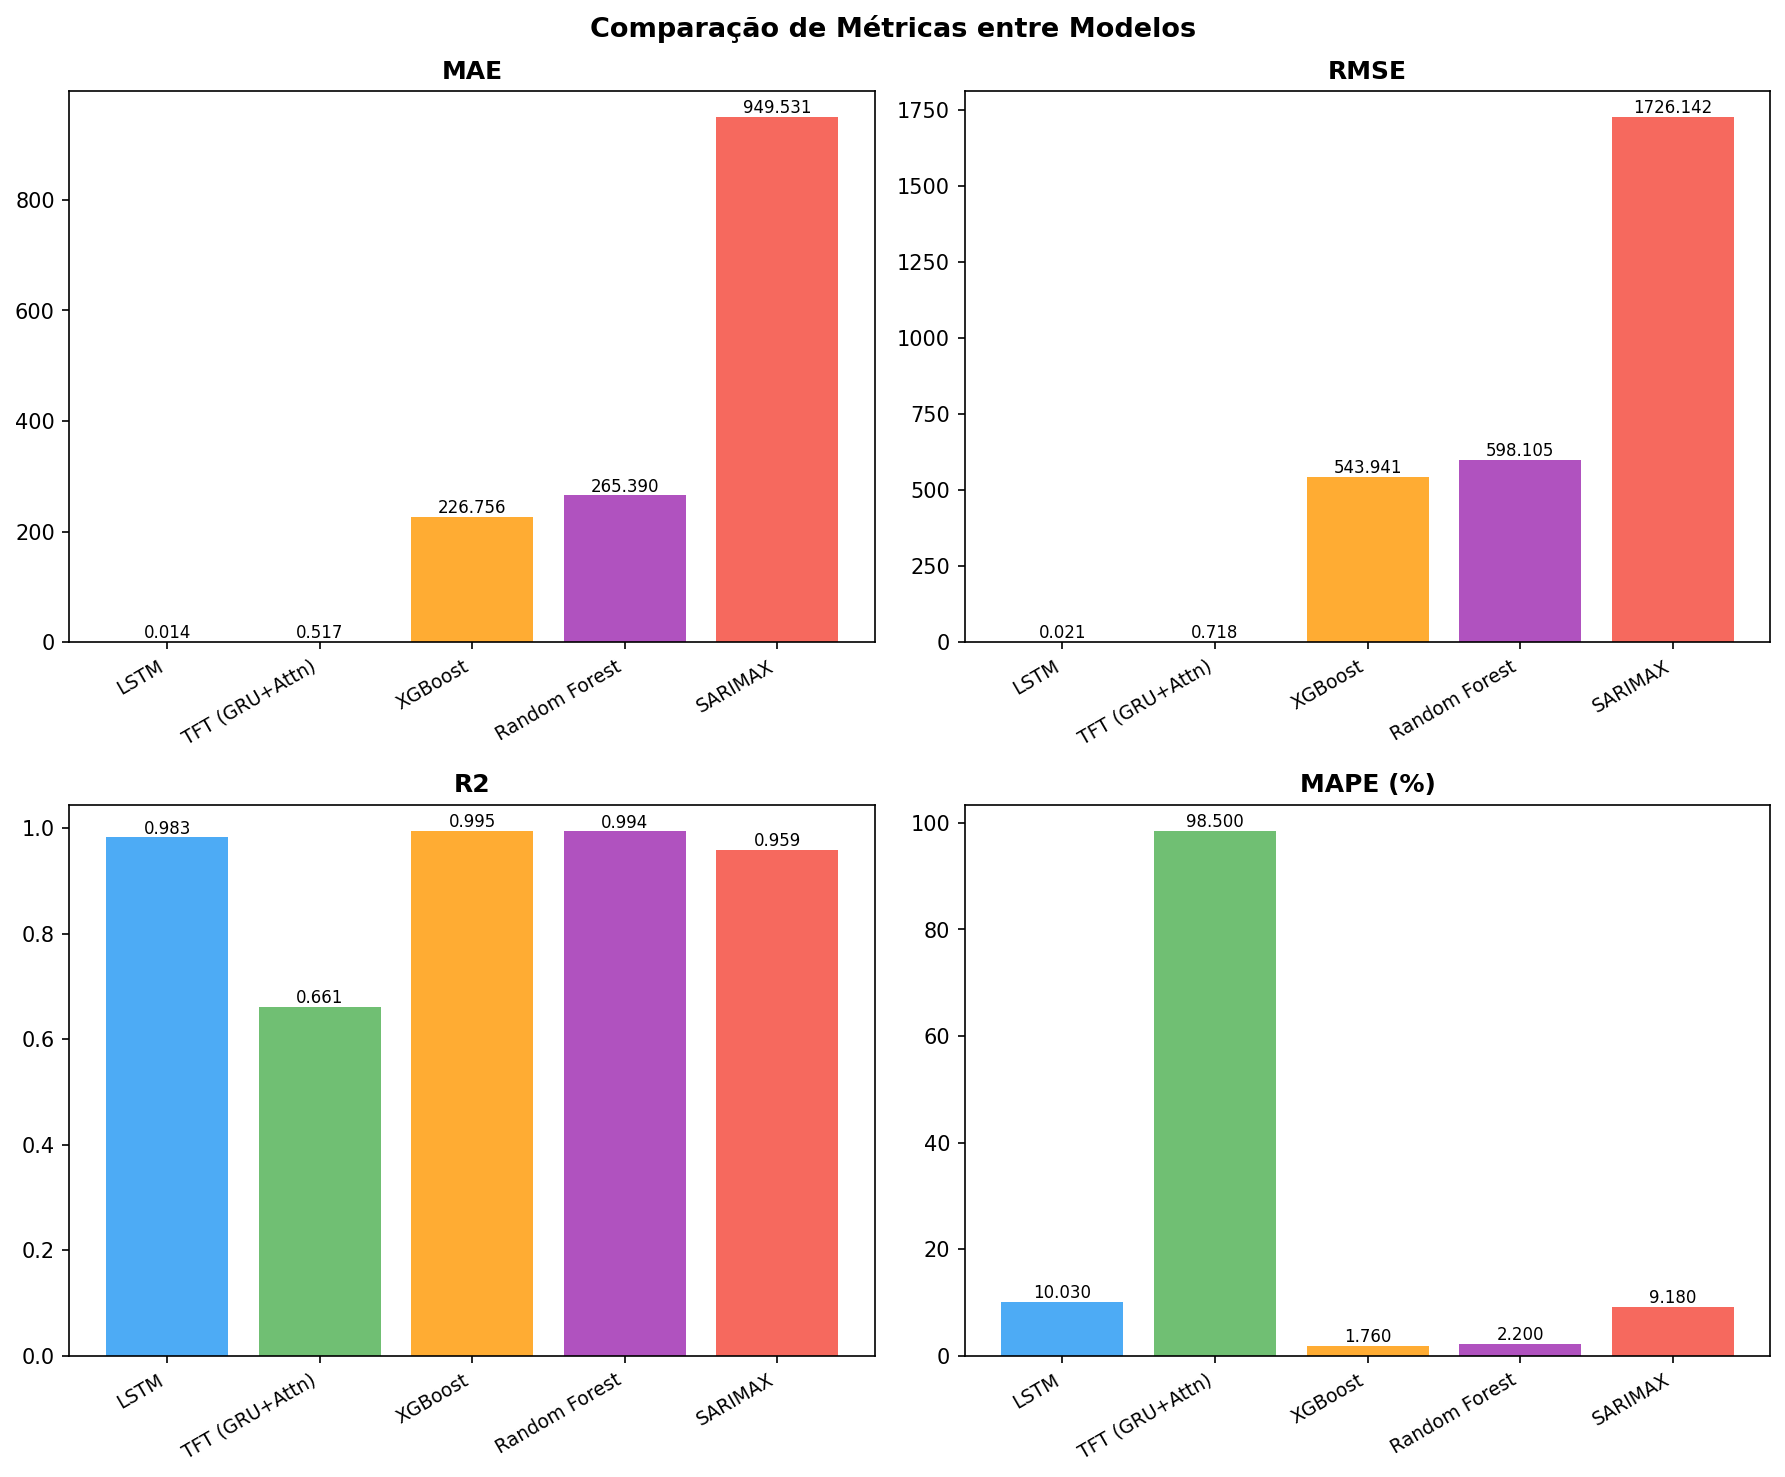


  03_distribuicao_residuos.png


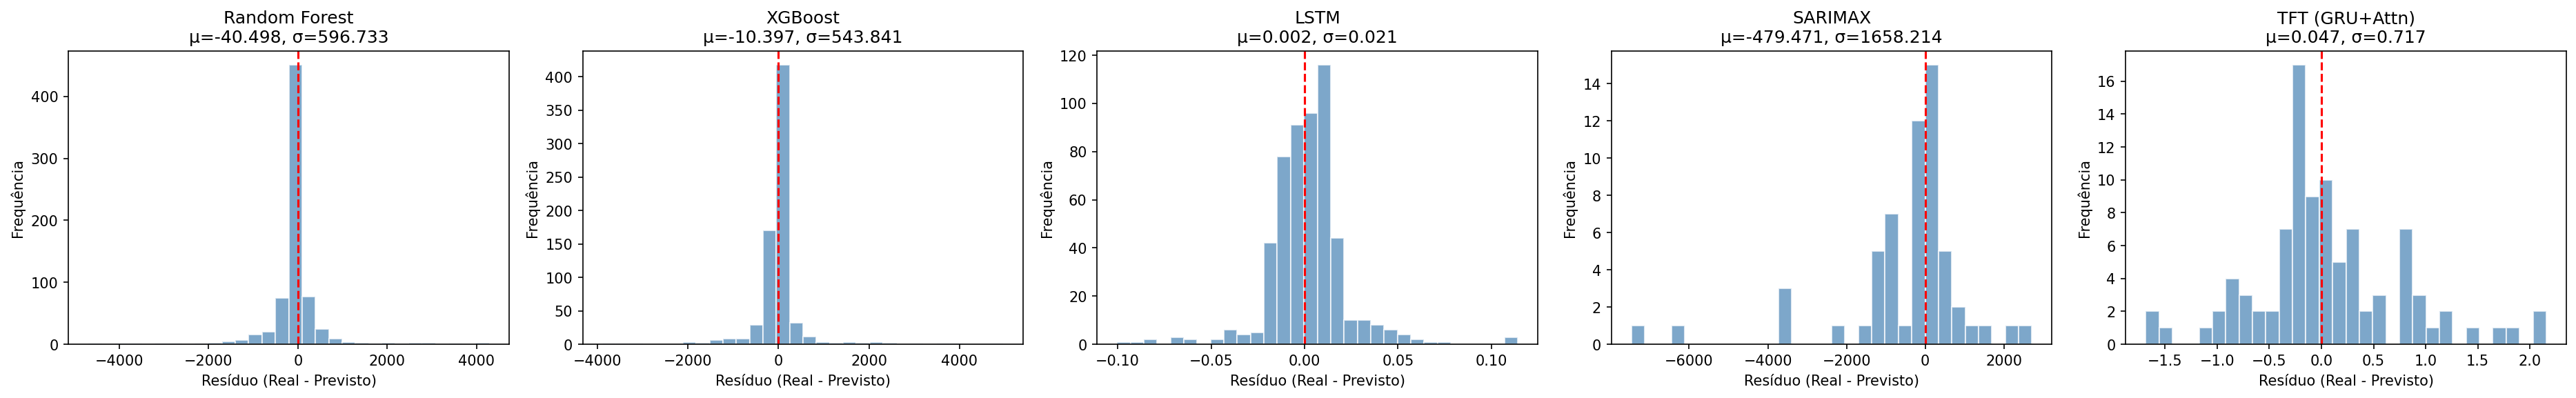


  04_ranking_modelos.png


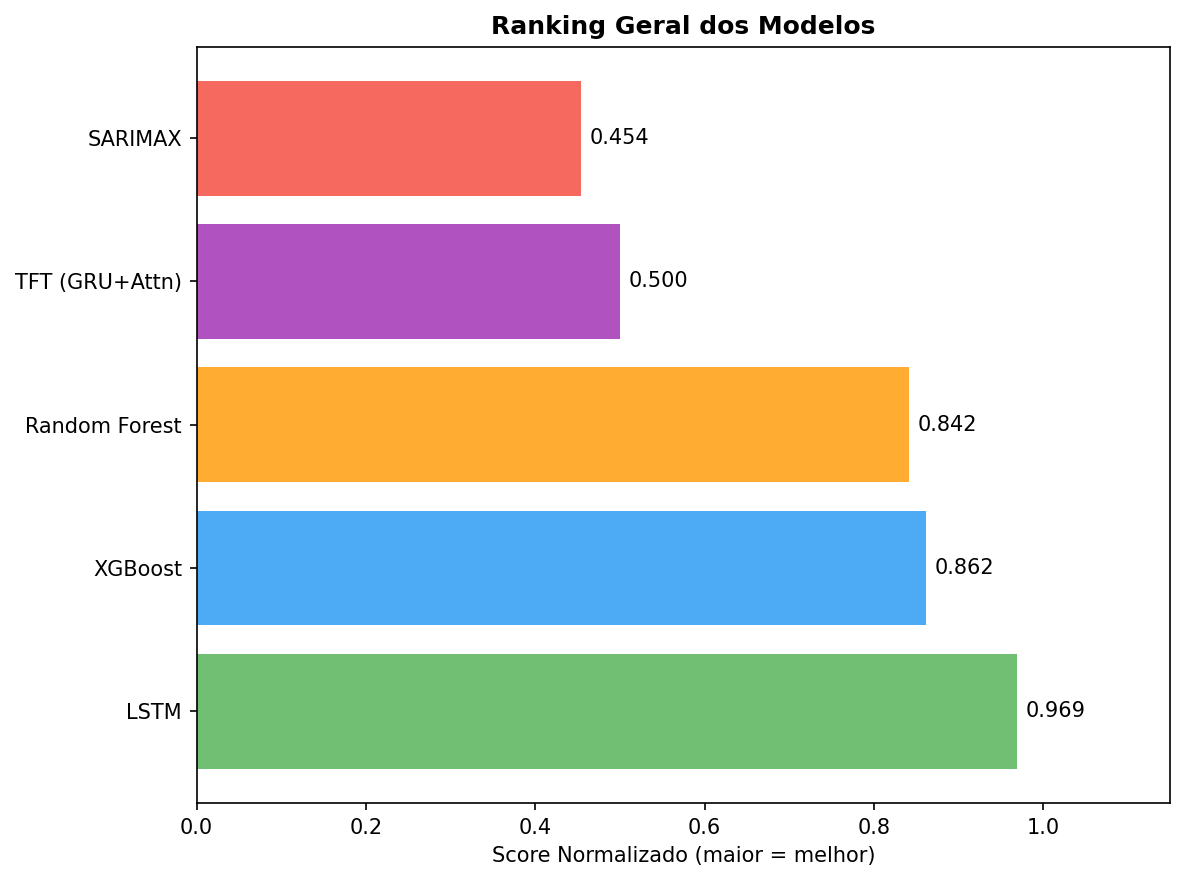

In [3]:
# 3. Visualizar resultados
import os
from IPython.display import Image, display

for dataset in ['inner', 'left', 'outer']:
    pasta = f'resultados_modelos/{dataset}'
    if os.path.exists(pasta):
        print(f"\n{'═' * 60}")
        print(f"  RESULTADOS: {dataset.upper()}")
        print(f"{'═' * 60}")
        for img in sorted(os.listdir(pasta)):
            if img.endswith('.png'):
                print(f"\n  {img}")
                display(Image(os.path.join(pasta, img), width=800))

In [4]:
# 4. Tabelas comparativas finais
import pandas as pd

for dataset, tabela in tabelas.items():
    print(f"\n{'═' * 60}")
    print(f"  RANKING — {dataset.upper()}")
    print(f"{'═' * 60}")
    display(tabela)


════════════════════════════════════════════════════════════
  RANKING — INNER
════════════════════════════════════════════════════════════


,modelo,MAE,RMSE,R2,MAPE (%),SMAPE (%),N_amostras
Rank,,,,,,,
1,LSTM,0.0148,0.0220,0.9803,9.75,9.28,535
2,TFT (GRU+Attn),0.4927,0.6843,0.6867,84.76,67.21,93
3,XGBoost,235.7633,556.4725,0.9946,1.85,1.82,706
4,Random Forest,263.2445,593.9615,0.9938,2.23,2.18,706
5,SARIMAX,949.5309,1726.1420,0.9592,9.18,8.54,58



════════════════════════════════════════════════════════════
  RANKING — LEFT
════════════════════════════════════════════════════════════


,modelo,MAE,RMSE,R2,MAPE (%),SMAPE (%),N_amostras
Rank,,,,,,,
1,LSTM,0.0129,0.0197,0.9844,8.43,7.96,558
2,TFT (GRU+Attn),0.5137,0.7152,0.6522,106.59,76.78,111
3,XGBoost,218.1351,520.6893,0.9952,1.71,1.68,730
4,Random Forest,266.3197,613.8555,0.9934,2.19,2.14,730
5,SARIMAX,952.0971,1726.6273,0.9592,9.21,8.57,58



════════════════════════════════════════════════════════════
  RANKING — OUTER
════════════════════════════════════════════════════════════


,modelo,MAE,RMSE,R2,MAPE (%),SMAPE (%),N_amostras
Rank,,,,,,,
1,LSTM,0.0140,0.0208,0.9825,10.03,10.19,538
2,TFT (GRU+Attn),0.5168,0.7182,0.6611,98.50,74.65,95
3,XGBoost,226.7560,543.9407,0.9948,1.76,1.74,709
4,Random Forest,265.3899,598.1053,0.9938,2.20,2.15,709
5,SARIMAX,949.5309,1726.1420,0.9592,9.18,8.54,58
